# Sentiment Analysis for Gender Bias (Memory Optimized)

This notebook implements the following analyses with memory efficiency:
1. **Gender Axis Construction**: Uses pre-computed `embedding_state.json` to build the axis without loading all post embeddings.
2. **Analyses**:
    - Gender Axis x Sentiment
    - Independence from Ideology
    - Robustness Check

In [1]:
import os
import json
import logging
import urllib3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Suppress warnings
urllib3.disable_warnings()
logging.getLogger("urllib3").setLevel(logging.CRITICAL)
logging.getLogger("elasticsearch").setLevel(logging.CRITICAL)

pd.set_option('display.max_columns', None)

In [ ]:
COL_W   = 3.3   # single-column width (inches)
FULL_W  = 7.0   # full-width figure   (inches)

GENDER_PALETTE = {"Female": "#FF7F0E", "Male": "#6E6E6E"}
COLORS = GENDER_PALETTE  # alias

plt.rcParams.update({
    'font.size':        50,
    'axes.titlesize':   50,
    'axes.labelsize':   13,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.titlesize': 17,
})

sns.set_style('whitegrid', {'axes.facecolor': 'white', 'figure.facecolor': 'white'})

FIG_DIR = 'images'
print('Figure style configured for ICWSM 2026 (AAAI two-column, 10pt body).')

## 1. Load Pre-computed Embeddings & Build Axis
Load `embedding_state.json` (Sum/Count per user) and `user_properties.json` to reconstruct user mean embeddings.

> **Note**: These files are stored in `./data/`.

In [120]:
DATA_DIR = "./data"

# Load files
try:
    with open(f"{DATA_DIR}/embedding_state.json", "r") as f:
        embedding_state = json.load(f)
    with open(f"{DATA_DIR}/user_properties.json", "r") as f:
        user_props = json.load(f)
    print(f"Loaded state for {len(embedding_state)} users.")
except FileNotFoundError:
    print("Error: embedding_state.json or user_properties.json not found in data/!")

# Reconstruct User Embeddings
user_vecs = []
user_genders = []
valid_sids = []

for sid, data in embedding_state.items():
    if sid not in user_props:
        continue
    
    if 'sum' in data and 'count' in data:
        vec_sum = np.array(data['sum'])
        count = max(data['count'], 1)
        mean_vec = vec_sum / count
        
        gender = user_props[sid].get('gender')
        if gender:
            gender = gender.capitalize()
            
        if gender in ['Male', 'Female']:
            user_vecs.append(mean_vec)
            user_genders.append(gender)
            valid_sids.append(sid)

X_users = np.array(user_vecs)
genders = np.array(user_genders)

if len(X_users) == 0:
    print("Error: No users found with valid gender! Check user_properties.json for gender field.")
else:
    global_mean = X_users.mean(axis=0)
    X_centered = X_users - global_mean

    fmask = (genders == "Female")
    mmask = (genders == "Male")

    muF = X_centered[fmask].mean(axis=0)
    muM = X_centered[mmask].mean(axis=0)

    u_gender = muF - muM
    u_gender = u_gender / np.linalg.norm(u_gender)

    print(f"Gender Axis built. Users: {fmask.sum()} Female, {mmask.sum()} Male.")

Loaded state for 921 users.
Gender Axis built. Users: 311 Female, 610 Male.


## 2. Load Scored Posts from File
Load the pre-computed sentiment scores from `data/sentiment_post_scores.csv`. Use this instead of 2a.

In [4]:
df = pd.read_csv(f"{DATA_DIR}/sentiment_post_scores.csv")
print(f"Loaded {len(df)} rows from {DATA_DIR}/sentiment_post_scores.csv")
df.head()

Loaded 191886 rows from ./data/sentiment_post_scores.csv


,id,SeedID,SeedName,FederalParty,gender,sentiment_val,axis_score
0,3609204661496624638_70925721743_candidates_feb...,6101,Julie Girard-Lemay,NDP,female,2,0.221531
1,3610232044802746395_70925721743_candidates_feb...,6101,Julie Girard-Lemay,NDP,female,0,-0.037509
2,3614535815808573395_70925721743_candidates_feb...,6101,Julie Girard-Lemay,NDP,female,1,0.061990
3,3616415165059375146_70925721743_candidates_feb...,6101,Julie Girard-Lemay,NDP,female,2,0.037026
4,3618229886200737878_70925721743_candidates_feb...,6101,Julie Girard-Lemay,NDP,female,2,0.090513


## 🥇 Analysis 1: Gender Axis x Sentiment
- Spearman Correlation
- Quartile Comparison (Q1 vs Q4)
- Mann-Whitney U Test

Spearman Correlation (Axis vs Sentiment): 0.5008 (p=0.0000e+00)
Median Sentiment Q1 (Most Male-aligned): 2.0
Median Sentiment Q4 (Most Female-aligned): 3.0
Mean Sentiment Q1: 1.68
Mean Sentiment Q4: 3.00
Mann-Whitney U Test: p=0.0000e+00


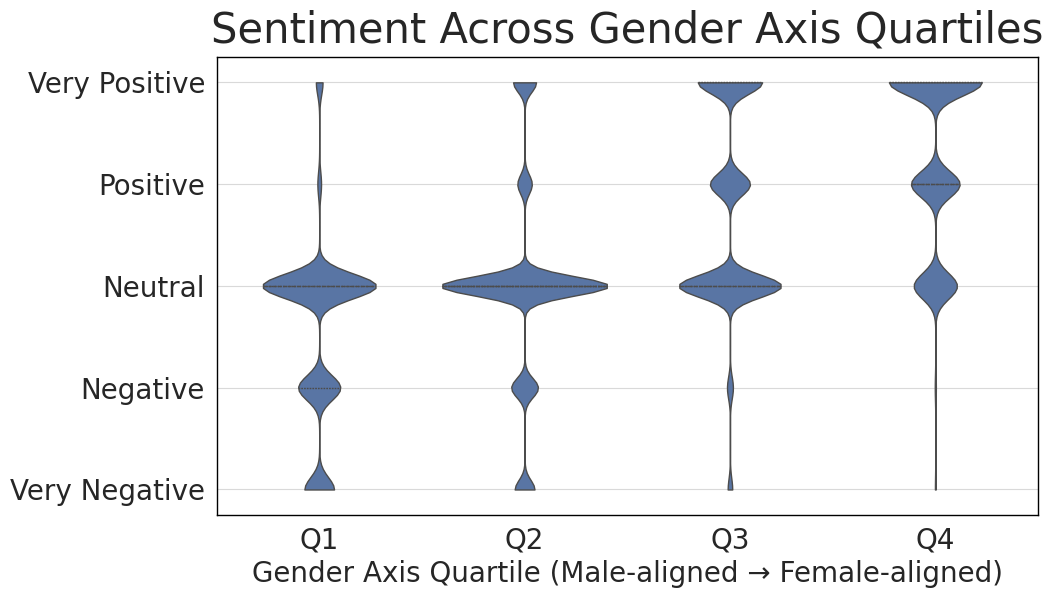

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import spearmanr, mannwhitneyu

# ---- Stats ----
corr, p_val = spearmanr(df['axis_score'], df['sentiment_val'])
print(f"Spearman Correlation (Axis vs Sentiment): {corr:.4f} (p={p_val:.4e})")

q1_thresh = df['axis_score'].quantile(0.25)
q4_thresh = df['axis_score'].quantile(0.75)

q1_posts = df[df['axis_score'] <= q1_thresh]
q4_posts = df[df['axis_score'] >= q4_thresh]

print(f"Median Sentiment Q1 (Most Male-aligned): {q1_posts['sentiment_val'].median()}")
print(f"Median Sentiment Q4 (Most Female-aligned): {q4_posts['sentiment_val'].median()}")
print(f"Mean Sentiment Q1: {q1_posts['sentiment_val'].mean():.2f}")
print(f"Mean Sentiment Q4: {q4_posts['sentiment_val'].mean():.2f}")

u_stat, u_p = mannwhitneyu(q1_posts['sentiment_val'], q4_posts['sentiment_val'], alternative='two-sided')
print(f"Mann-Whitney U Test: p={u_p:.4e}")

# ---- Style (white, paper) ----
plt.style.use("default")
sns.set_theme(
    style="whitegrid",
    context="paper",
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "grid.color": "0.85",
        "font.size": 13,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    },
)

# ---- Quartiles ----
quart = pd.cut(
    df["axis_score"],
    bins=4,
    labels=["Q1", "Q2", "Q3", "Q4"],
    include_lowest=True
)
sns.set_context("paper", font_scale=2.5)
# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 6.5), facecolor="white")
ax.set_facecolor("white")

sns.violinplot(
    x=quart,
    y=df["sentiment_val"],
    ax=ax,
    inner="quartile",
    cut=0,
    linewidth=1
)

ax.set_title("Sentiment Across Gender Axis Quartiles", pad=10, fontsize=30)
ax.set_xlabel("Gender Axis Quartile (Male-aligned → Female-aligned)", fontsize=20)

sentiment_map = {
    0: "Very Negative",
    1: "Negative",
    2: "Neutral",
    3: "Positive",
    4: "Very Positive",
}
ax.set_ylim(-0.25, 4.25)
ax.set_yticks(list(sentiment_map.keys()))
ax.set_yticklabels(list(sentiment_map.values()))
ax.set_ylabel("", fontsize=25)

ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/icwsm_fig7.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 🥈 Analysis 2: Independence from Ideology
Check sentiment gap within each party.

In [ ]:
if len(df) > 0:
    df['FederalParty'] = df['FederalParty'].astype(str).str.strip()
    parties = df['FederalParty'].unique()
    party_results = []

    for party in parties:
        party_df = df[df['FederalParty'] == party]
        if len(party_df) < 50: continue

        q1_local = party_df[party_df['axis_score'] <= party_df['axis_score'].quantile(0.25)]
        q4_local = party_df[party_df['axis_score'] >= party_df['axis_score'].quantile(0.75)]

        diff = q4_local['sentiment_val'].mean() - q1_local['sentiment_val'].mean()
        party_results.append({"Party": party, "Sentiment_Diff (Q4-Q1)": diff, "N_posts": len(party_df)})

    res_df = pd.DataFrame(party_results)
    print(res_df)

    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=res_df, x='Party', y='Sentiment_Diff (Q4-Q1)')
    plt.axhline(0, color='black', linestyle='--')
    plt.title("Sentiment Difference (Female-aligned - Male-aligned) by Party")
    plt.show()

## 🥉 Analysis 3: Robustness Check (Candidate Aggregated)
Correlation of candidate-level mean axis score and mean sentiment.

Candidate-Level Spearman Correlation: 0.7573 (p=2.9326e-172)


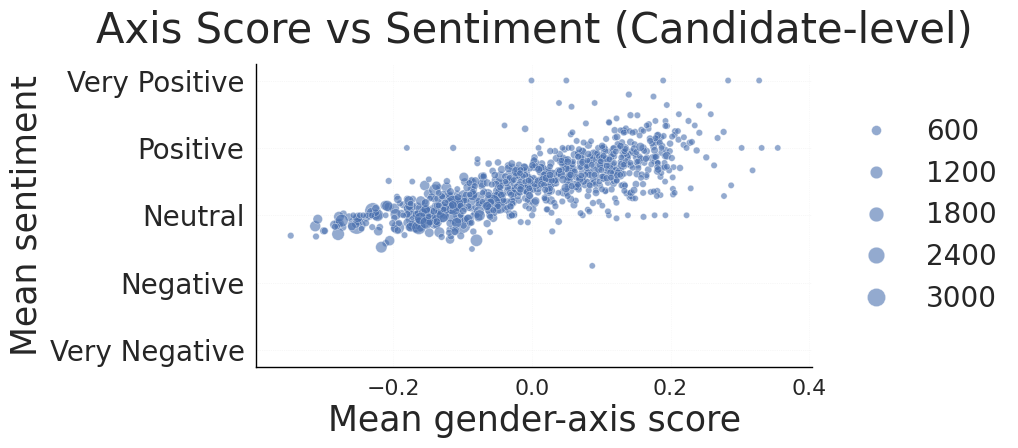

In [116]:
if len(df) > 0:
    cand_stats = df.groupby(['SeedID', 'SeedName']).agg({
        'axis_score': 'mean',
        'sentiment_val': 'mean',
        'id': 'count'
    }).rename(columns={'id': 'count'}).reset_index()

    cand_corr, cand_p = spearmanr(
        cand_stats['axis_score'],
        cand_stats['sentiment_val']
    )
    print(f"Candidate-Level Spearman Correlation: {cand_corr:.4f} (p={cand_p:.4e})")

    sentiment_map = {
        0: "Very Negative",
        1: "Negative",
        2: "Neutral",
        3: "Positive",
        4: "Very Positive",
    }

    with sns.plotting_context("paper", font_scale=1.8):
        fig, ax = plt.subplots(figsize=(FULL_W, 3.2))

        sns.scatterplot(
            data=cand_stats,
            x='axis_score',
            y='sentiment_val',
            size='count',
            alpha=0.6,
            sizes=(20, 200),
            legend='brief',
            ax=ax
        )

        ax.set_ylim(-0.25, 4.25)
        ax.set_yticks(list(sentiment_map.keys()))
        ax.set_yticklabels(list(sentiment_map.values()))


        ax.set_title("Axis Score vs Sentiment (Candidate-level)", pad=15,fontsize=30)
        ax.set_xlabel("Mean gender-axis score", fontsize=25)
        ax.set_ylabel("Mean sentiment", fontsize=25)

        ax.tick_params(axis='y', labelsize=20)

        ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.4)
        ax.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.3)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlim(
            cand_stats['axis_score'].min() - 0.05,
            cand_stats['axis_score'].max() + 0.05
        )
        leg = ax.legend(
            title="",
            frameon=False,
            loc="center left",
            fontsize=20,
            bbox_to_anchor=(1.02, 0.5)
        )
        plt.tight_layout(rect=[0, 0, 1.5, 1.5])
        plt.savefig(
            f"{FIG_DIR}/icwsm_fig8.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )
        plt.show()